In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od

In [ ]:
od.download("https://www.kaggle.com/datasets/manjilkarki/deepfake-and-real-images/code")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: deepfake
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/manjilkarki/deepfake-and-real-images


100%|██████████| 1.68G/1.68G [00:29<00:00, 61.7MB/s]


In [ ]:
!pip install numpy
!pip install matplotlib
!pip install tensorflow

In [ ]:
import os
os.listdir('deepfake-and-real-images')

['Dataset']

In [ ]:
import tensorflow as tf
train_directory = "/content/deepfake-and-real-images/Dataset/Train"
val_directory = "/content/deepfake-and-real-images/Dataset/Validation"
test_directory = "/content/deepfake-and-real-images/Dataset/Test"

CLASS_NAMES = ['Real','Fake']
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_directory,
    labels='inferred',
    label_mode='categorical',
    class_names=CLASS_NAMES,
    color_mode='rgb',
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=99
)

Found 140002 files belonging to 2 classes.


In [ ]:
import tensorflow as tf
train_directory = "/content/deepfake-and-real-images/Dataset/Train"
val_directory = "/content/deepfake-and-real-images/Dataset/Validation"
test_directory = "/content/deepfake-and-real-images/Dataset/Test"
CLASS_NAMES = ['Real','Fake']
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_directory,
    labels='inferred',
    label_mode='categorical',
    class_names=CLASS_NAMES,
    color_mode='rgb',
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=99
)

Found 10905 files belonging to 2 classes.


In [ ]:
import tensorflow as tf
train_directory = "/content/deepfake-and-real-images/Dataset/Train"
val_directory = "/content/deepfake-and-real-images/Dataset/Validation"
test_directory = "/content/deepfake-and-real-images/Dataset/Test"
CLASS_NAMES = ['Real','Fake']
val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    val_directory,
    labels='inferred',
    label_mode='categorical',
    class_names=CLASS_NAMES,
    color_mode='rgb',
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=99
)

Found 39428 files belonging to 2 classes.


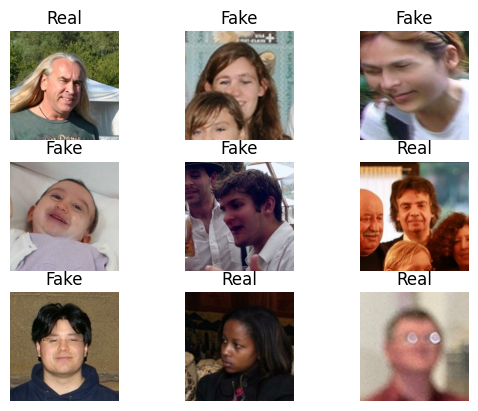

In [ ]:
import matplotlib.pyplot as plt
for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(CLASS_NAMES[tf.argmax(labels[i]).numpy()])
    plt.axis("off")

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
with tf.device('/device:GPU:0'):
  model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(256, 256, 3)),
    tf.keras.layers.Rescaling(1./255, name='rescaling'),

    tf.keras.layers.Conv2D(filters=16, kernel_size=(4, 4), strides=2, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2),

    tf.keras.layers.Conv2D(filters=36, kernel_size=(2, 2), strides=1, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=1),
     tf.keras.layers.Conv2D(filters=64, kernel_size=(2, 2), strides=1, activation='relu'), #Added layer
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=1), #Added layer
    tf.keras.layers.Conv2D(filters=128, kernel_size=(2, 2), strides=1, activation='relu'), #Added layer
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=1), #Added layer
tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
tf.keras.layers.Dense(32, activation='relu'),

    tf.keras.layers.Dense(2, activation='softmax')
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 127, 127, 16)        │             784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 127, 127, 16)        │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 62, 62, 36)          │           2,340 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 62, 62, 36)          │             144 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 61, 61, 36)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 64)          │           9,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 60, 60, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 59, 59, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 58, 58, 128)         │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 58, 58, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 57, 57, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 415872)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      53,231,744 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │              66 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 53,288,422 (203.28 MB)

 Trainable params: 53,287,934 (203.28 MB)

 Non-trainable params: 488 (1.91 KB)

In [ ]:
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import TopKCategoricalAccuracy

loss_function = CategoricalCrossentropy(from_logits=False)
metrics = [CategoricalCrossentropy(name='accuracy'), TopKCategoricalAccuracy(k=3)]
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_dataset, validation_data=val_dataset, epochs=8)

Epoch 1/8
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 227s 49ms/step - accuracy: 0.7851 - loss: 1.1656 - val_accuracy: 0.8135 - val_loss: 0.5048
Epoch 2/8
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 191s 44ms/step - accuracy: 0.9309 - loss: 0.1715 - val_accuracy: 0.8787 - val_loss: 0.3226
Epoch 3/8
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 205s 44ms/step - accuracy: 0.9505 - loss: 0.1241 - val_accuracy: 0.8780 - val_loss: 0.3020
Epoch 4/8
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 201s 44ms/step - accuracy: 0.9656 - loss: 0.0857 - val_accuracy: 0.8309 - val_loss: 0.4670
Epoch 5/8
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 211s 48ms/step - accuracy: 0.9755 - loss: 0.0613 - val_accuracy: 0.8890 - val_loss: 0.3430
Epoch 6/8
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 266s 49ms/step - accuracy: 0.9825 - loss: 0.0447 - val_accuracy: 0.9340 - val_loss: 0.3217
Epoch 7/8
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 260s 49ms/step - accuracy: 0.9853 - loss: 0.0397 - val_accuracy: 0.9349 - val_loss: 0.3764
Epoch 8/8
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 263s 49ms/step - accuracy: 0.9873 -

341/341 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step


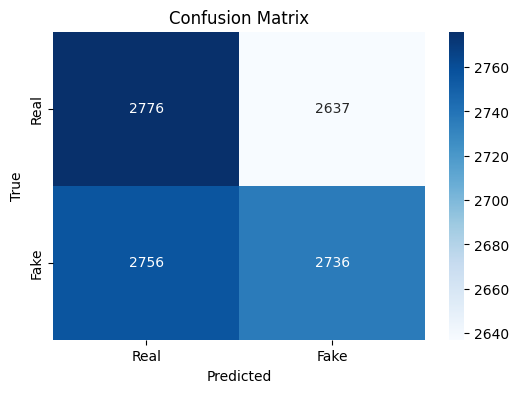

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

predictions = model.predict(test_dataset)
predicted_labels = np.argmax(predictions, axis=1)

true_labels = []
for images, labels in test_dataset:
    true_labels.extend(np.argmax(labels, axis=1)) # Use labels directly, no need for .numpy()
true_labels = np.array(true_labels)

cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"Test accuracy: {test_accuracy}")

341/341 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.8879 - loss: 0.5947
Test accuracy: 0.8850985765457153
341/341 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8867 - loss: 0.5926
Test accuracy: 0.8850985765457153


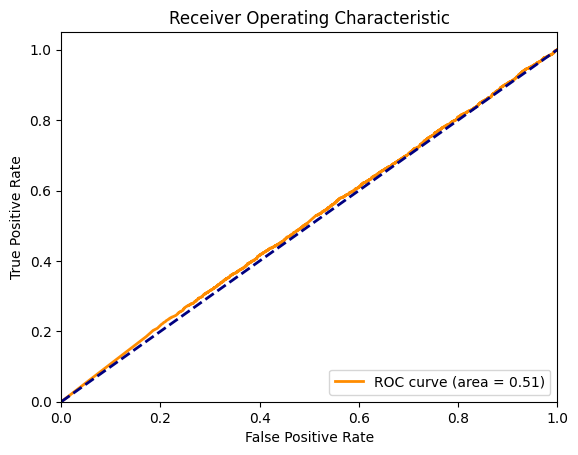

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
probabilities = predictions[:, 1]
fpr, tpr, _ = roc_curve(true_labels, probabilities)
roc_auc = auc(fpr, tpr)
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

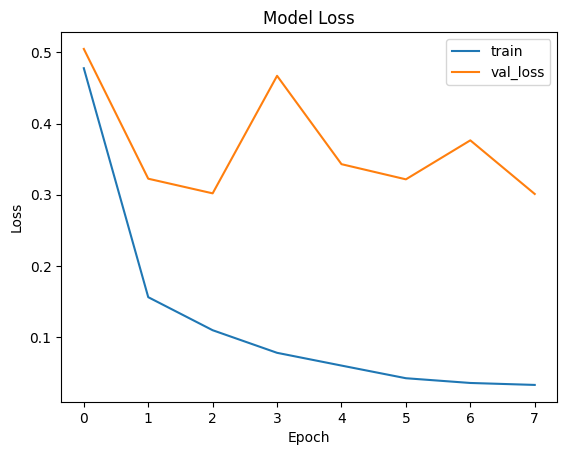

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['train', 'val_loss'])
plt.show ()

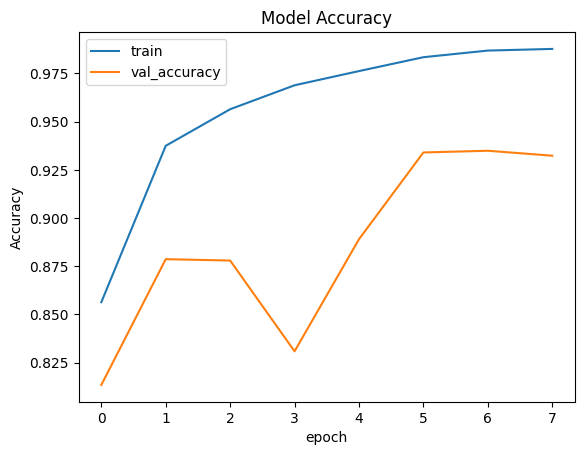

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('epoch')
plt.ylabel('Accuracy')
plt.legend(['train','val_accuracy'])
plt.show()

In [ ]:
import numpy as np

predictions = model.predict(test_dataset)
predicted_classes = np.argmax(predictions, axis=1)

print(predictions.shape)

341/341 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step
(10905, 2)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
for image, labels in test_dataset.take(1):
  predicted = model.predict(image)
  predicted_classes = np.argmax(predicted, axis=1)

  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image[i].numpy().astype("uint8"))
    plt.title(f"True: {CLASS_NAMES[tf.argmax(labels[i]).numpy()]}, Pred: {CLASS_NAMES[predicted_classes[i]]}")
    plt.axis("off")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 622ms/step
